In [1]:
## automatically reload any modules read below that might have changed (e.g. plots)
%reload_ext autoreload
%autoreload 2

In [2]:
# importing plotting and locus tools: 
import NEOfaster as nf
import NEOMOD3 as nm3  

In [3]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from urllib.request import urlopen
from io import StringIO
import numpy as np
import astropy.units as u
from astropy.time import Time
from numpy import sin, cos
from astropy.coordinates import EarthLocation, get_body_barycentric_posvel, solar_system_ephemeris 
from astropy.coordinates import SkyCoord, get_sun, GCRS, GeocentricTrueEcliptic
import pyarrow as pa
import adam_core.coordinates
from adam_core.time import Timestamp
from adam_core.coordinates import CartesianCoordinates, Origin
from adam_core.constants import KM_P_AU, S_P_DAY
from adam_core.orbits import Orbits
from adam_core.utils import get_perturber_state
from adam_core.coordinates.origin import OriginCodes
from scipy.interpolate import RegularGridInterpolator

#importing the neomod3.py file for the 4D array
import NEOMOD3 as nm3

In [4]:
neo_score, a, e, i = nf.compute_neomod3_weight(d_au=0.20, ddot_kms=3.0)


test_neomod = nf.compute_neomod3_weight( 
    d_au = 0.20,
    ddot_kms = 3.0,
    
)

print("NEOMOD3 weight score, a, e , i:", test_neomod)
print("neo_score:", neo_score)
print("a:", a)
print("e:", e)
print("i:", i)

NEOMOD3 weight score, a, e , i: (0.38768, 1.7775913691728702, 0.3357516710390056, 25.139852694560748)
neo_score: 0.38768
a: 1.7775913691728702
e: 0.3357516710390056
i: 25.139852694560748


In [5]:
df, array4D, H_center, a_center, e_center, i_center = nm3.getNEOMOD3orbits()

In [6]:
# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0
obstime_str = "2025-09-23T00:00:00"

 
N_rate = 101 #2 mins 30 sec, for 31 = 4 mins 20 sec so around 50 mins for 101
dra_vals  = np.linspace(-0.6, 0.6, N_rate)
ddec_vals = np.linspace(-0.6, 0.6, N_rate)


vlam_edges = np.linspace(-0.6, 0.6, 121)
vbet_edges = np.linspace(-0.6, 0.6, 121)


H = np.zeros((len(vbet_edges)-1, len(vlam_edges)-1), dtype=float)

for dra in dra_vals:
    for ddec in ddec_vals:
        vlam, vbet = nf.radec_rates_to_ecliptic_rates1(ra0_deg, dec0_deg, dra, ddec)
        w_int = nf.weight_marginalized_over_d_and_ddot(array4D=array4D, H_center=H_center, a_center=a_center, e_center=e_center, i_center=i_center,
                                                    ra_deg=ra0_deg, dec_deg=dec0_deg, dra_deg_day=dra, ddec_deg_day=ddec,
                                                    H0=19.0, i0=25.9, obstime_str=obstime_str)
        
        i = np.searchsorted(vlam_edges, vlam) - 1
        j = np.searchsorted(vbet_edges, vbet) - 1
        if 0 <= i < H.shape[1] and 0 <= j < H.shape[0]:
            H[j, i] += w_int


/tmp/ipykernel_4173571/2078373854.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")


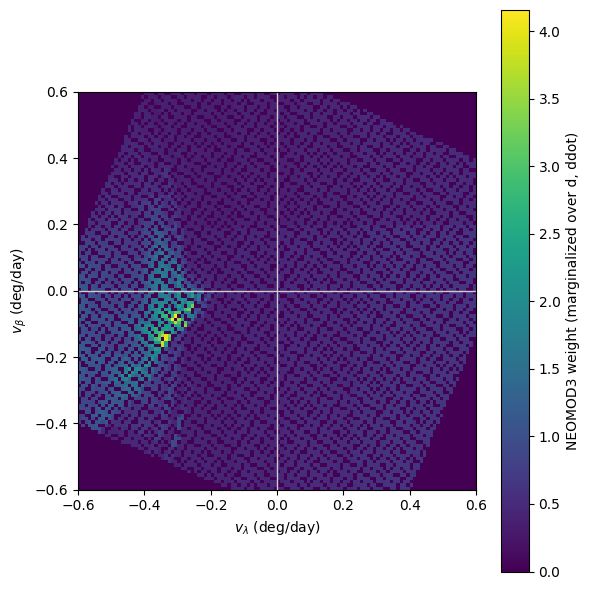

Min: 0.0
Max: 4.156960539999998
Mean: 0.36515139302907523
Std: 0.3838164016430552
Variance: 0.14731503017022304


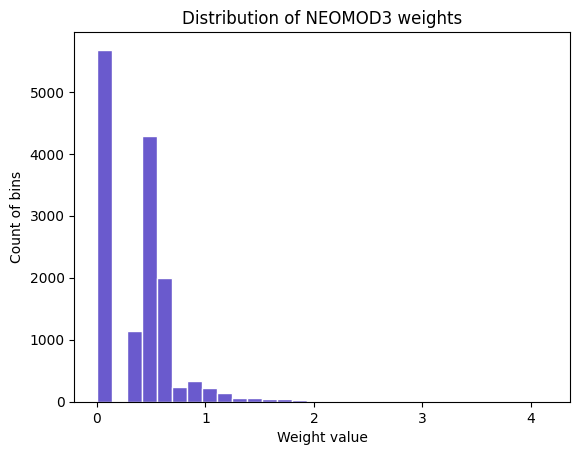

Nonzero mean: 0.6029331567043554
Nonzero std: 0.31603500198641243


In [7]:
from matplotlib import cm
plt.figure(figsize=(6.0, 6.0))
extent = [vlam_edges[0], vlam_edges[-1], vbet_edges[0], vbet_edges[-1]]
 
my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")
im = plt.imshow(H, origin="lower", extent=extent, cmap=my_viridis, aspect="equal")


plt.colorbar(label="NEOMOD3 weight (marginalized over d, ddot)")

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
#plt.title("v_lambda–v_beta distribution (integrated over d [0.05,5] AU, ddot [−60,60] km/s)\n"
#          f"{obstime_str}")
plt.tight_layout()
plt.show()
print("Min:", np.nanmin(H))
print("Max:", np.nanmax(H))
print("Mean:", np.nanmean(H))
print("Std:", np.nanstd(H))
print("Variance:", np.nanvar(H))
plt.figure()
plt.hist(H.flatten(), bins=30, color='slateblue', edgecolor='white')
plt.xlabel("Weight value")
plt.ylabel("Count of bins")
plt.title("Distribution of NEOMOD3 weights")
plt.show()
nonzero = H[H > 0]
print("Nonzero mean:", np.mean(nonzero))
print("Nonzero std:", np.std(nonzero))


In [9]:
scores = []
for dra in [0.0, 0.1, 0.2]:
    for ddec in [0.0, 0.1, 0.2]:
        s, a, e, i = nf.compute_neomod3_weight(
            1.0, 0.0, ra_deg=10, dec_deg=20,
            dra_deg_per_day=dra, ddec_deg_per_day=ddec
        )
        scores.append(s)
        print(f"dra={dra:.2f}, ddec={ddec:.2f} → score={s:.6f}")

dra=0.00, ddec=0.00 → score=0.000324
dra=0.00, ddec=0.10 → score=0.000000
dra=0.00, ddec=0.20 → score=0.000000
dra=0.10, ddec=0.00 → score=0.000000
dra=0.10, ddec=0.10 → score=0.000000
dra=0.10, ddec=0.20 → score=0.000000
dra=0.20, ddec=0.00 → score=0.000000
dra=0.20, ddec=0.10 → score=0.000000
dra=0.20, ddec=0.20 → score=0.000000
